### CNN (Convolutional Neural Network) 모델을 활용한 시장 예측

#### 📌 CNN이란?
CNN은 이미지 처리에 주로 사용되는 딥러닝 모델이지만, 시계열 데이터에서도 뛰어난 성능을 발휘합니다. CNN은 시퀀스 데이터에서 특징을 추출하고 패턴을 인식하는 데 강력합니다.

#### 🔍 CNN의 장점
- 특징 추출: 여러 필터를 사용해 데이터에서 중요한 특징을 찾아냅니다.
- 계산 효율성: 병렬 계산이 가능하여 빠르게 학습합니다.
- 시계열 패턴 인식: 시계열 데이터의 미세한 패턴을 인식합니다.

​

In [1]:
import pyupbit
import pandas as pd
import numpy as np
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
# 데이터 수집
df = pyupbit.get_ohlcv("KRW-BTC", interval="day", count=200)

# 'close' 가격만 사용
data = df['close'].values.reshape(-1, 1)

In [3]:
# 데이터 정규화
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [4]:
# 시퀀스 데이터 생성
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

In [5]:
seq_length = 10
X, y = create_sequences(scaled_data, seq_length)

In [6]:
# 데이터 분할
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [7]:
# CNN 입력 형식 맞춤
X_train = X_train.reshape(X_train.shape[0], seq_length, 1)
X_test = X_test.reshape(X_test.shape[0], seq_length, 1)

In [8]:
# CNN 모델 생성
model = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(seq_length, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

In [9]:
# 모델 컴파일
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 9, 64)             192       
                                                                 
 max_pooling1d (MaxPooling1  (None, 4, 64)             0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 256)               0         
                                                                 
 dense (Dense)               (None, 50)                12850     
                                                                 
 dropout (Dropout)           (None, 50)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 51        
                                                        

In [10]:
# 모델 훈련
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/50
10/10 [==============================] - 0s 9ms/step - loss: 0.1355 - val_loss: 0.0054
Epoch 2/50
10/10 [==============================] - 0s 2ms/step - loss: 0.0300 - val_loss: 0.0117
Epoch 3/50
10/10 [==============================] - 0s 2ms/step - loss: 0.0242 - val_loss: 0.0090
Epoch 4/50
10/10 [==============================] - 0s 3ms/step - loss: 0.0207 - val_loss: 0.0059
Epoch 5/50
10/10 [==============================] - 0s 3ms/step - loss: 0.0178 - val_loss: 0.0048
Epoch 6/50
10/10 [==============================] - 0s 3ms/step - loss: 0.0197 - val_loss: 0.0046
Epoch 7/50
10/10 [==============================] - 0s 2ms/step - loss: 0.0154 - val_loss: 0.0049
Epoch 8/50
10/10 [==============================] - 0s 2ms/step - loss: 0.0179 - val_loss: 0.0046
Epoch 9/50
10/10 [==============================] - 0s 2ms/step - loss: 0.0178 - val_loss: 0.0051
Epoch 10/50
10/10 [==============================] - 0s 2ms/step - loss: 0.0178 - val_loss: 0.0046
Epoch 11/50
10/10 [

In [11]:
# 예측
y_pred = model.predict(X_test)

2/2 [==============================] - 0s 2ms/step


In [12]:
# 예측값과 실제값을 원래 스케일로 되돌리기
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

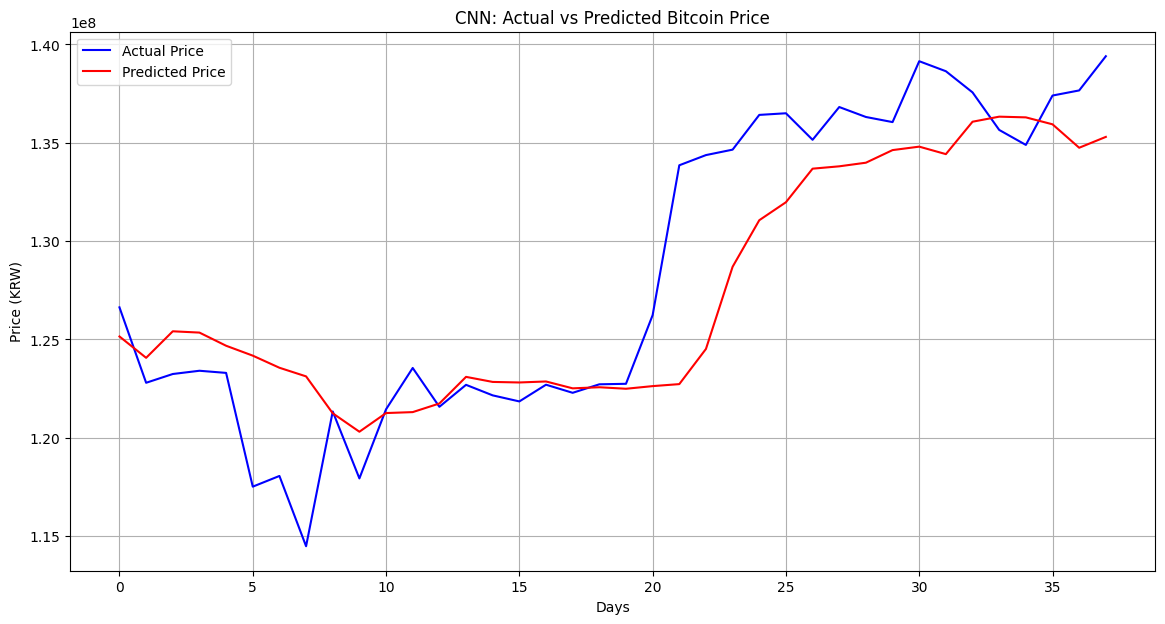

In [13]:
# 예측 결과 시각화
plt.figure(figsize=(14, 7))
plt.plot(y_test_inv, label='Actual Price', color='blue')
plt.plot(y_pred_inv, label='Predicted Price', color='red')
plt.title('CNN: Actual vs Predicted Bitcoin Price')
plt.xlabel('Days')
plt.ylabel('Price (KRW)')
plt.legend()
plt.grid()
plt.show()